<a href="https://colab.research.google.com/github/SweetlinN/Manufacturing_quality_rating_prediction/blob/main/Manufacturing_quality_prediction2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import  r2_score,mean_absolute_error,mean_absolute_percentage_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# (REGRESSION)problem statement - quality rating prediction

In [2]:
#The manufacturing dataset consists of the following columns:

#1.	Temperature (°C): This column represents the temperature during the manufacturing process,
#measured in degrees Celsius. Temperature plays a critical role in many manufacturing processes,
#influencing material properties and product quality.

#2.	Pressure (kPa): The pressure applied during the manufacturing process, measured in kilopascals (kPa).
#Pressure can affect the material transformation and the overall outcome of the manufacturing process.

#3.	Temperature x Pressure: This feature is an interaction term between temperature and pressure,
#which captures the combined effect of these two process parameters.

#4.	Material Fusion Metric: A derived metric calculated as the sum of the square of temperature and the cube of pressure.
#It represents a material fusion-related measurement during the manufacturing process.

#5.	Material Transformation Metric: Another derived metric calculated as the cube of temperature minus the square of pressure.
#It provides insight into material transformation dynamics.

#6.	Quality Rating: The target variable, 'Quality Rating,' represents the overall quality rating of the produced items.
#Quality is a crucial aspect of manufacturing, and this rating serves as a measure of the final product's quality.


# 2.Data Gathering

In [3]:
# load data

In [4]:
from google.colab import files
uploaded = files.upload()

Saving manufacturing.csv to manufacturing.csv


In [5]:
df = pd.read_csv('manufacturing.csv')

In [6]:
# first five rows of the dataset

In [7]:
df.head(5)

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [8]:
# last five rows of the dataset

In [9]:
df.tail()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06,100.000000
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06,99.999997
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07,99.989318
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06,99.999975
3956,163.359996,24.332133,3974.897121,41092.392901,4.358913e+06,100.000000


# 3.(EDA) Read and Explore the data

In [10]:
df.shape

(3957, 6)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB


In [12]:
df.describe()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
count,3957.000000,3957.000000,3957.000000,3957.000000,3.957000e+03,3957.000000
mean,200.034704,14.815558,2955.321308,48127.183128,1.003645e+07,96.260179
std,58.135717,5.772040,1458.224940,23812.213513,7.599356e+06,12.992262
min,100.014490,5.003008,513.706875,10156.971955,9.999462e+05,1.000000
25%,150.871296,9.692984,1798.247303,27626.929091,3.433810e+06,99.941129
50%,198.603371,14.832557,2678.277782,44611.452164,7.833390e+06,99.999997
75%,251.366552,19.749680,3929.058261,67805.443846,1.588251e+07,100.000000
max,299.992804,24.999132,7365.018714,103756.181544,2.699783e+07,100.000000


In [13]:
df.isna().sum()

,0
Temperature (°C),0
Pressure (kPa),0
Temperature x Pressure,0
Material Fusion Metric,0
Material Transformation Metric,0
Quality Rating,0


# 4. data visualization

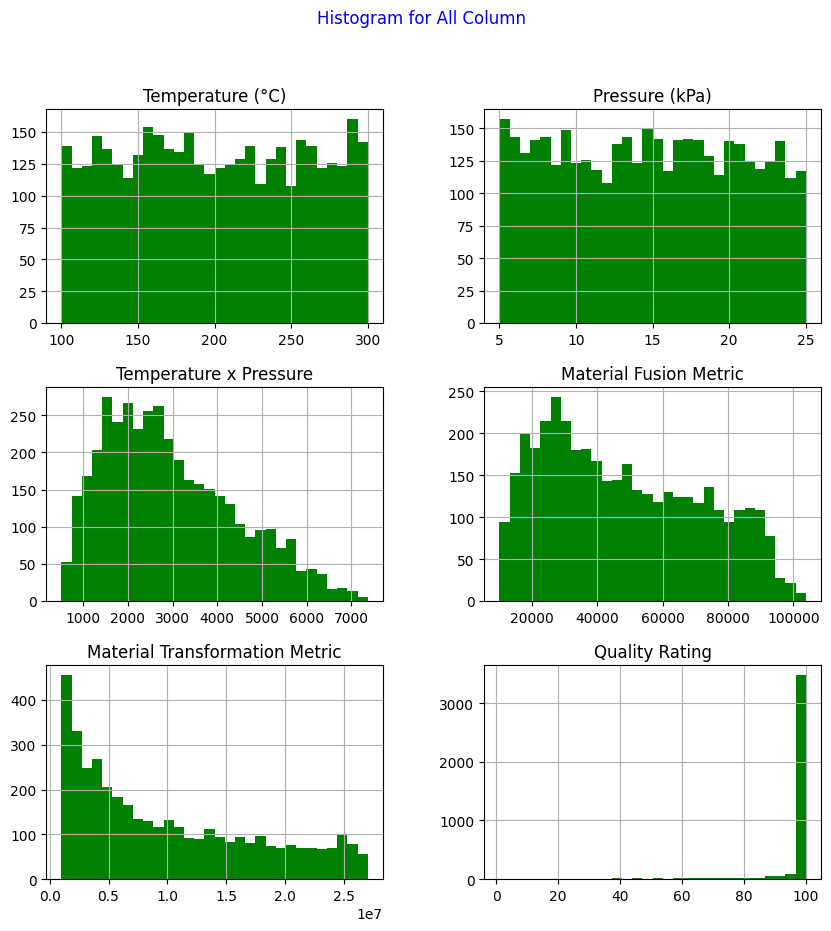

In [14]:
df.hist(figsize=(10,10),color='green',bins=30)
plt.suptitle("Histogram for All Column",color='blue')
plt.show()


<Axes: >

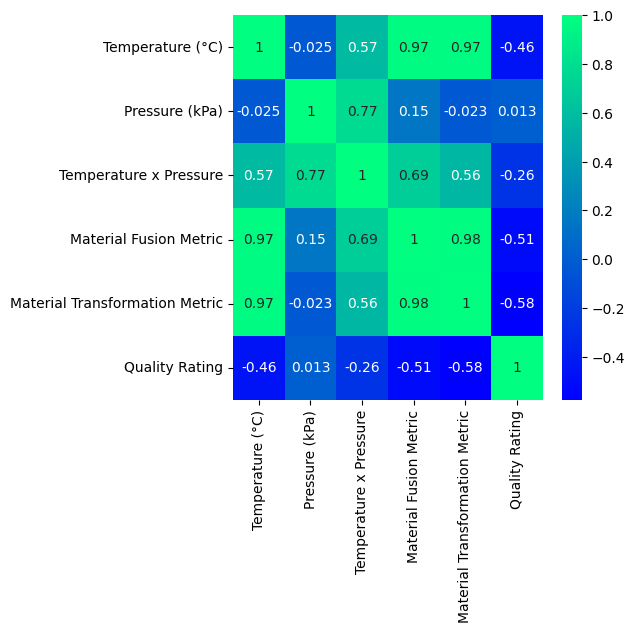

In [15]:
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(),annot=True,linecolor='g',cbar='False',cmap='winter')

In [16]:
df.head()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


# 5. Train Test Split

In [17]:
X = df.drop(['Quality Rating'],axis=1)
y = df['Quality Rating']

In [18]:
X

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06
...,...,...,...,...,...
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06


In [19]:
features = X.columns.to_list()

In [20]:
print(len (features))

5


In [21]:
y

,Quality Rating
0,99.999971
1,99.985703
2,99.999758
3,99.999975
4,100.000000
...,...
3952,100.000000
3953,99.999997
3954,99.989318
3955,99.999975


In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


# 6.Train and evaluate the model

In [23]:
model = XGBRegressor()
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred

array([  4.9062085,  98.882774 ,  96.91265  ,  99.941864 ,  99.999596 ,
        99.999596 , 100.00004  ,  99.99693  ,  99.99981  ,  57.236076 ,
        99.99971  ,  99.99999  ,  99.99969  ,  99.9985   ,  99.93631  ,
        99.99981  ,  99.999596 , 100.00006  , 100.00006  ,  97.90701  ,
        99.99969  ,  98.951126 ,  99.99981  ,  57.21722  , 100.00004  ,
        48.77556  ,  99.98638  ,  99.999596 ,  99.93303  ,  99.99967  ,
        99.99989  ,  99.999596 ,  99.999596 ,  99.999596 ,  99.99981  ,
       100.00462  ,  99.999596 ,  99.07753  ,  99.999596 ,  99.999596 ,
        99.999596 , 100.00004  ,  42.686718 ,  98.19977  ,  99.963875 ,
        99.99858  ,  99.99999  ,  51.213074 , 100.00004  ,  99.992966 ,
        99.40864  ,  99.999596 ,  99.999596 ,  63.887936 ,  21.491638 ,
        99.9923   ,  99.9985   ,  99.99894  ,  99.999596 ,  99.99981  ,
        99.989334 ,  99.99999  ,  99.9985   ,  99.96409  ,  99.99868  ,
        99.9942   ,  99.99915  ,  99.999596 ,  99.99971  , 100.0

In [26]:
for value in y_pred:
  print(value)

4.9062085
98.882774
96.91265
99.941864
99.999596
99.999596
100.00004
99.99693
99.99981
57.236076
99.99971
99.99999
99.99969
99.9985
99.93631
99.99981
99.999596
100.00006
100.00006
97.90701
99.99969
98.951126
99.99981
57.21722
100.00004
48.77556
99.98638
99.999596
99.93303
99.99967
99.99989
99.999596
99.999596
99.999596
99.99981
100.00462
99.999596
99.07753
99.999596
99.999596
99.999596
100.00004
42.686718
98.19977
99.963875
99.99858
99.99999
51.213074
100.00004
99.992966
99.40864
99.999596
99.999596
63.887936
21.491638
99.9923
99.9985
99.99894
99.999596
99.99981
99.989334
99.99999
99.9985
99.96409
99.99868
99.9942
99.99915
99.999596
99.99971
100.00004
99.99353
99.998276
99.999825
46.839233
99.999596
100.00006
99.82311
99.99989
99.999596
99.999596
99.99981
99.99955
99.999596
99.999596
99.99857
100.00006
97.23801
93.28721
99.999596
5.3027782
99.999596
99.999596
99.999596
99.999596
100.00004
100.00006
99.999596
99.844894
99.999596
100.00004
99.999596
24.336206
99.999596
99.51054
99.99981


In [32]:

df = pd.DataFrame({
    "y_test": y_test,
    "y_pred": y_pred
})

print(df)

          y_test      y_pred
149     4.052686    4.906209
1025   98.873036   98.882774
2153   96.914933   96.912651
720    99.951543   99.941864
325    99.999999   99.999596
...          ...         ...
1226   99.999999  100.007538
736   100.000000   99.999687
3782   99.999677   99.999596
927   100.000000   99.999809
3775  100.000000   99.999596

[792 rows x 2 columns]


In [33]:
df["error"] = df["y_test"] - df["y_pred"]
print(df)

          y_test      y_pred     error
149     4.052686    4.906209 -0.853522
1025   98.873036   98.882774 -0.009738
2153   96.914933   96.912651  0.002282
720    99.951543   99.941864  0.009679
325    99.999999   99.999596  0.000404
...          ...         ...       ...
1226   99.999999  100.007538 -0.007539
736   100.000000   99.999687  0.000313
3782   99.999677   99.999596  0.000081
927   100.000000   99.999809  0.000191
3775  100.000000   99.999596  0.000404

[792 rows x 3 columns]


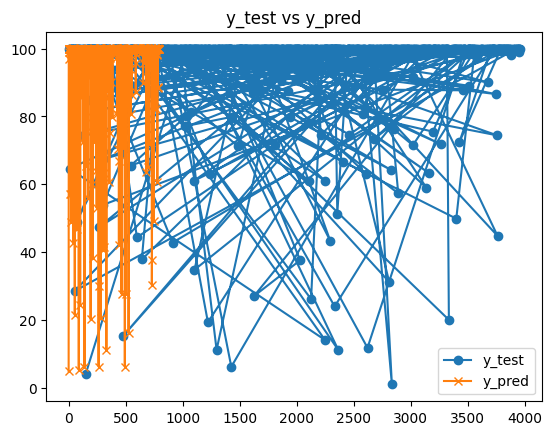

In [34]:
import matplotlib.pyplot as plt

plt.plot(y_test, label="y_test", marker='o')
plt.plot(y_pred, label="y_pred", marker='x')
plt.legend()
plt.title("y_test vs y_pred")
plt.show()

In [27]:
acc = r2_score(y_test, y_pred)*100
MAE = mean_absolute_error(y_test,y_pred)
MAPE =mean_absolute_percentage_error(y_test,y_pred)

In [28]:
print(acc)
print(MAE)
print(MAPE)

99.8224062034223
0.13505784214443256
0.00972178663112096


# 7.Retrain the  model

In [29]:
model = XGBRegressor(colsample_bytree=0.8,learning_rate=0.2,max_depth=5,n_estimators = 50,sub_samples=0.8)
model.fit(X_train,y_train)
xgb_predict = model.predict(X_test)

In [30]:
acc = r2_score(y_test, xgb_predict)*100
MAE = mean_absolute_error(y_test,xgb_predict)
MAPE =mean_absolute_percentage_error(y_test,xgb_predict)

In [31]:
print(acc)
print(MAE)
print(MAPE)

99.82802997330668
0.13480355019897294
0.00986986819827447
